In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),   # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize
])

In [3]:
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 108MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.75MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 49.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [4]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [5]:
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 60000
Test size: 10000


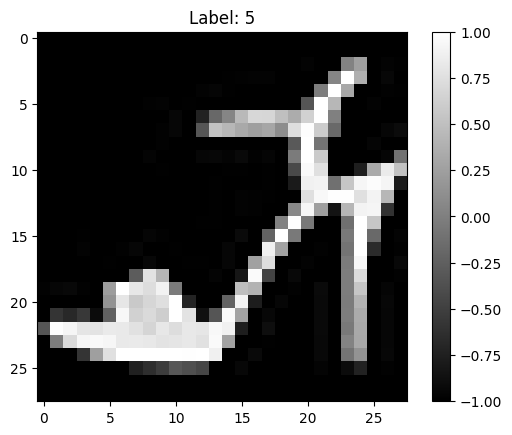

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch
images, labels = next(iter(train_loader))

# Convert tensor to numpy
img = images[0].numpy().squeeze()

plt.imshow(img, cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.colorbar()
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolution layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (28x28 → 28x28)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (28x28 → 28x28)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)  # (28 → 14 → 7)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28 → 14
        x = self.pool(F.relu(self.conv2(x)))  # 14 → 7

        x = x.view(-1, 64 * 7 * 7)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [9]:
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
epochs = 5

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 409.9945
Epoch [2/5], Loss: 266.2514
Epoch [3/5], Loss: 220.7061
Epoch [4/5], Loss: 190.9238
Epoch [5/5], Loss: 165.9705


In [12]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 91.42%
